In [ ]:
import numpy as np
import pandas as pd


# df to Wasza wygenerowana tabela
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

NameError: name 'df' is not defined

In [3]:
import requests

# Współrzędne (domyślnie: Warszawa)
latitude = 52.2297
longitude = 21.0122

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "current": ["temperature_2m", "relative_humidity_2m", "apparent_temperature", "precipitation", "wind_speed_10m"],
    "hourly": ["temperature_2m", "precipitation_probability"],
    "timezone": "auto"  # Automatycznie dopasowuje strefę czasową
}

response = requests.get(url, params=params)
data = response.json()

# Odczyt danych bieżących
current = data.get("current", {})
units = data.get("current_units", {})

print("--- AKTUALNA POGODA ---")
print(f"Czas: {current.get('time')}")
print(f"Temperatura: {current.get('temperature_2m')} {units.get('temperature_2m')}")
print(f"Odczuwalna: {current.get('apparent_temperature')} {units.get('apparent_temperature')}")
print(f"Wilgotność: {current.get('relative_humidity_2m')} {units.get('relative_humidity_2m')}")
print(f"Wiatr: {current.get('wind_speed_10m')} {units.get('wind_speed_10m')}")

# Podgląd pierwszych 5 godzin z prognozy
print("\n--- NAJBLIŻSZE GODZINY ---")
hourly = data.get("hourly", {})
for i in range(5):
    time_str = hourly["time"][i]
    temp = hourly["temperature_2m"][i]
    pop = hourly["precipitation_probability"][i]
    print(f"{time_str} -> {temp}°C, szansa na opady: {pop}%")

--- AKTUALNA POGODA ---
Czas: 2026-09-28T16:45
Temperatura: 20.6 °C
Odczuwalna: 19.0 °C
Wilgotność: 48 %
Wiatr: 9.0 km/h

--- NAJBLIŻSZE GODZINY ---
2026-09-28T00:00 -> 12.9°C, szansa na opady: 0%
2026-09-28T01:00 -> 12.2°C, szansa na opady: 0%
2026-09-28T02:00 -> 11.3°C, szansa na opady: 0%
2026-09-28T03:00 -> 10.9°C, szansa na opady: 0%
2026-09-28T04:00 -> 10.6°C, szansa na opady: 0%


In [ ]:
import pandas as pd
import requests

# Parametry zapytania
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 38.7223,
    "longitude": -9.1393,
    "start_date": "2024-08-01",
    "end_date": "2026-08-01",
    "hourly": [
        "temperature_2m",
        "apparent_temperature",
        "relative_humidity_2m",
        "direct_normal_irradiance",
        "shortwave_radiation",
        "cloud_cover",
        "wind_speed_10m"
    ],
    "timezone": "auto"
}

print("Pobieranie pełnego zbioru cech pogodowych z Open-Meteo...")
response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    hourly = data.get("hourly", {})

    # Tworzenie DataFrame
    df = pd.DataFrame({
        "timestamp": pd.to_datetime(hourly["time"]),
        "temperature_2m": hourly["temperature_2m"],
        "apparent_temperature": hourly["apparent_temperature"],
        "relative_humidity_2m": hourly["relative_humidity_2m"],
        "direct_normal_irradiance": hourly["direct_normal_irradiance"],
        "shortwave_radiation": hourly["shortwave_radiation"],
        "cloud_cover": hourly["cloud_cover"],
        "wind_speed_10m": hourly["wind_speed_10m"]
    })

    # Cechy inżynieryjne (Feature Engineering pod ML i HVAC)
    df["cooling_demand"] = (df["temperature_2m"] - 23.0).clip(lower=0)
    df["heating_demand"] = (19.0 - df["temperature_2m"]).clip(lower=0)
    df["temp_rolling_mean_6h"] = df["temperature_2m"].rolling(window=6, min_periods=1).mean()
    
    print(f"Pobrano {len(df)} rekordów godzinowych.")
    print("\nPierwsze 5 wierszy:")
    print(df.head())
else:
    print(f"Błąd HTTP: {response.status_code}")
    print(response.text)

Pobieranie pełnego zbioru cech pogodowych z Open-Meteo...
Pobrano 17544 rekordów godzinowych.
Zapisano do pliku: weather_features_lisbon_2024_2026.csv

Pierwsze 5 wierszy:
            timestamp  temperature_2m  apparent_temperature  \
0 2024-08-01 00:00:00            19.8                  20.6   
1 2024-08-01 01:00:00            19.5                  20.6   
2 2024-08-01 02:00:00            19.5                  20.6   
3 2024-08-01 03:00:00            19.5                  20.4   
4 2024-08-01 04:00:00            19.6                  20.1   

   relative_humidity_2m  direct_normal_irradiance  shortwave_radiation  \
0                    84                       0.0                  0.0   
1                    86                       0.0                  0.0   
2                    87                       0.0                  0.0   
3                    86                       0.0                  0.0   
4                    85                       0.0                  0.0   

   c

In [69]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.inspection import permutation_importance

# 1. Wczytanie danych z Twoimi nagłówkami
df = pd.read_csv('weather_features_lisbon_2024_2026.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. INŻYNIERIA CECH CZASOWYCH (Dla algorytmów bazujących na odległości)

# A. Cykl dobowy (Godziny) - krytyczny dla włączania/wyłączania urządzeń w ciągu dnia
df['hour'] = df['timestamp'].dt.hour
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

# B. Cykl tygodniowy (Dni tygodnia) - krytyczny dla pracy hybrydowej i weekendów
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['sin_week'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['cos_week'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# C. Pora roku (Dzień w roku zamiast miesięcy) - wyłapuje gładko sezony (zima/lato)
df['day_of_year'] = df['timestamp'].dt.dayofyear
df['sin_year'] = np.sin(2 * np.pi * df['day_of_year'] / 366)
df['cos_year'] = np.cos(2 * np.pi * df['day_of_year'] / 366)

# 3. Przygotowanie danych do modelu
# W tym przykładzie jako nasz "cel" (y) weźmiemy cooling_demand, 
# ale w docelowym rozwiązaniu będzie to całkowite zużycie w kWh wyliczone z profili urządzeń.
y = df['cooling_demand'] 

# X to nasze cechy pogodowe i czasowe (usuwamy to co tekstowe i nasz cel)
features_to_drop = ['timestamp', 'cooling_demand', 'hour', 'day_of_week', 'day_of_year']
X = df.drop(columns=features_to_drop)

# 4. Podział na zbiór treningowy i testowy bez tasowania (szeregi czasowe)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 5. Skalowanie - BEZWZGLĘDNIE WYMAGANE DLA KNN
# Bez skalowania 'cloud_cover' (np. 100) zdominuje 'sin_hour' (od -1 do 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Trening KNN
knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn.fit(X_train_scaled, y_train)

# 7. SPRAWDZENIE, CO JEST NAJWAŻNIEJSZE (Permutation Importance)
# To pozwoli Ci zobaczyć, czy model woli Twoje dane z pogody, cykl dobowy, czy tygodniowy
results = permutation_importance(knn, X_test_scaled, y_test, scoring='neg_mean_absolute_error', random_state=42)

print("\n--- Znaczenie poszczególnych cech (co faktycznie jest potrzebne) ---")
importance_df = pd.DataFrame({'cecha': X.columns, 'waznosc': results.importances_mean})
importance_df = importance_df.sort_values(by='waznosc', ascending=False)
print(importance_df)


--- Znaczenie poszczególnych cech (co faktycznie jest potrzebne) ---
                       cecha   waznosc
0             temperature_2m  0.366249
1       apparent_temperature  0.329917
8       temp_rolling_mean_6h  0.268647
2       relative_humidity_2m  0.239409
4        shortwave_radiation  0.064887
3   direct_normal_irradiance  0.045216
14                  sin_year  0.035096
6             wind_speed_10m  0.025122
9                   sin_hour  0.012797
5                cloud_cover  0.010504
13                is_weekend  0.009764
10                  cos_hour  0.005464
15                  cos_year  0.004652
11                  sin_week  0.002130
7             heating_demand  0.000044
12                  cos_week -0.012646


In [70]:
import pandas as pd
import numpy as np
import io

# Przykładowe dane z Twojego wejścia
csv_data = """timestamp,temperature_2m,apparent_temperature,relative_humidity_2m,direct_normal_irradiance,shortwave_radiation,cloud_cover,wind_speed_10m,cooling_demand,heating_demand,temp_rolling_mean_6h
2024-08-01 00:00:00,19.8,20.6,84,0.0,0.0,36,11.5,0.0,0.0,19.8
2024-08-01 01:00:00,19.5,20.6,86,0.0,0.0,67,10.1,0.0,0.0,19.65"""

df = pd.read_csv(io.StringIO(csv_data))

# 1. Konwersja na typ datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. day_week (1-7)
# dt.dayofweek zwraca 0 dla poniedziałku i 6 dla niedzieli, więc dodajemy +1
df['day_week'] = df['timestamp'].dt.dayofweek + 1

# 3. is_weekend (0/1)
# Skoro day_week to 1-7, weekend wypada dla wartości 6 (sobota) i 7 (niedziela)
df['is_weekend'] = (df['day_week'] >= 6).astype(int)

# 4. Cykl dobowy (sin_hour, cos_hour)
hour = df['timestamp'].dt.hour
df['sin_hour'] = np.sin(2 * np.pi * hour / 24)
df['cos_hour'] = np.cos(2 * np.pi * hour / 24)

# 5. Pora roku (sin_year, cos_year)
day_of_year = df['timestamp'].dt.dayofyear
df['sin_year'] = np.sin(2 * np.pi * day_of_year / 366)
df['cos_year'] = np.cos(2 * np.pi * day_of_year / 366)

# Opcjonalnie: usunięcie oryginalnego timestampa, jeśli nie będzie już potrzebny w modelu
# df = df.drop(columns=['timestamp'])

print(df[['timestamp', 'day_week', 'is_weekend', 'sin_hour', 'cos_hour', 'sin_year', 'cos_year']])

            timestamp  day_week  is_weekend  sin_hour  cos_hour  sin_year  \
0 2024-08-01 00:00:00         4           0  0.000000  1.000000 -0.507415   
1 2024-08-01 01:00:00         4           0  0.258819  0.965926 -0.507415   

   cos_year  
0 -0.861702  
1 -0.861702  


In [13]:
import pandas as pd
import numpy as np

# Nazwy plików (zmień input_filename na właściwą nazwę Twojego pliku, jeśli jest inna)
input_filename = "weather_features_lisbon_2024_2026.csv"
output_filename = "weather_features_transformed.csv"

# 1. Wczytanie dużego pliku CSV
df = pd.read_csv(input_filename)

# 2. Konwersja kolumny timestamp na typ datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 3. Tworzenie nowych cech czasowych
# Dzień tygodnia (1-7, gdzie 1 to poniedziałek, 7 to niedziela)
df['day_week'] = df['timestamp'].dt.dayofweek + 1

# Flaga weekendu (1 jeśli sobota/niedziela, w przeciwnym razie 0)
df['is_weekend'] = (df['day_week'] >= 6).astype(int)

# Cykl dobowy (z godzin 0-23)
hour = df['timestamp'].dt.hour
df['sin_hour'] = np.sin(2 * np.pi * hour / 24)
df['cos_hour'] = np.cos(2 * np.pi * hour / 24)
df['hour'] = hour  # Zachowujemy godzinę jako cechę numeryczną, jeśli będzie potrzebna
# Pora roku (z dni w roku 1-366)
day_of_year = df['timestamp'].dt.dayofyear
df['sin_year'] = np.sin(2 * np.pi * day_of_year / 366)
df['cos_year'] = np.cos(2 * np.pi * day_of_year / 366)

# 4. Usunięcie oryginalnej kolumny timestamp (zamiana na nowe kolumny)
df = df.drop(columns=['timestamp'])

# 5. Zapis przetworzonych danych do nowego pliku CSV
df.to_csv(output_filename, index=False)

print(f"Plik pomyślnie przetworzony i zapisany jako: {output_filename}")
print("\nPodgląd pierwszych 3 wierszy nowego zestawu danych:")
print(df.head(3))

Plik pomyślnie przetworzony i zapisany jako: weather_features_transformed.csv

Podgląd pierwszych 3 wierszy nowego zestawu danych:
   temperature_2m  apparent_temperature  relative_humidity_2m  \
0            19.8                  20.6                    84   
1            19.5                  20.6                    86   
2            19.5                  20.6                    87   

   direct_normal_irradiance  shortwave_radiation  cloud_cover  wind_speed_10m  \
0                       0.0                  0.0           36            11.5   
1                       0.0                  0.0           67            10.1   
2                       0.0                  0.0           93            10.1   

   cooling_demand  heating_demand  temp_rolling_mean_6h  day_week  is_weekend  \
0             0.0             0.0                 19.80         4           0   
1             0.0             0.0                 19.65         4           0   
2             0.0             0.0       

In [ ]:
import pandas as pd
import random
# Wczytanie przekształconego pliku CSV
filename = "weather_features_transformed.csv"
df = pd.read_csv(filename)

# Dodanie nowych kolumn binarnych (domyślnie zainicjalizowanych na 0)
df["is_dog_in"] = 1       # Domyślnie 1, bo pies zazwyczaj zostaje w mieszkaniu
df["man_at_office"] = 0   # 0 = w domu / wolne, 1 = w biurze
df["girl_at_office"] = 0  # 0 = w domu / wolne, 1 = w biurze
df["weekend_away"] = random.binomialvariate(n=1, p=0.67)    # 1 jeśli wyjechali na weekend

# Nadpisanie lub zapisanie do nowego pliku
output_filename = "weather_features_with_behavior.csv"
df.to_csv(output_filename, index=False)

print(f"Dodano kolumny i zapisano do: {output_filename}")
print("\nNowy zestaw kolumn:")
print(list(df.columns))
print("\nPodgląd pierwszego wiersza:")
print(df.head(1))

Dodano kolumny i zapisano do: weather_features_transformed.csv

Nowy zestaw kolumn:
['temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'direct_normal_irradiance', 'shortwave_radiation', 'cloud_cover', 'wind_speed_10m', 'cooling_demand', 'heating_demand', 'temp_rolling_mean_6h', 'day_week', 'is_weekend', 'sin_hour', 'cos_hour', 'hour', 'sin_year', 'cos_year', 'is_dog_in', 'man_at_office', 'girl_at_office', 'weekend_away']

Podgląd pierwszego wiersza:
   temperature_2m  apparent_temperature  relative_humidity_2m  \
0            19.8                  20.6                    84   

   direct_normal_irradiance  shortwave_radiation  cloud_cover  wind_speed_10m  \
0                       0.0                  0.0           36            11.5   

   cooling_demand  heating_demand  temp_rolling_mean_6h  ...  is_weekend  \
0             0.0             0.0                  19.8  ...           0   

   sin_hour  cos_hour  hour  sin_year  cos_year  is_dog_in  man_at_office  \
0     

In [41]:
import numpy as np
import pandas as pd

# Wczytanie pliku
filename = "weather_features_transformed.csv"
df = pd.read_csv(filename)

# Ustawienie ziarna losowości dla powtarzalności wyników (opcjonalne)
np.random.seed(42)

# -------------------------------------------------------------
# 1. OBECNOŚĆ W BIURZE (9:00 - 17:00)
# -------------------------------------------------------------
# Zgodnie ze scenariuszem pasmo pracy to 9:00–17:00 (godziny 9..16 włącznie)
office_hours = (df["hour"] >= 9) & (df["hour"] < 17)

# Mężczyzna: poniedziałek (1), wtorek (2), środa (3)
df["man_at_office"] = (df["day_week"].isin([1, 2, 3]) & office_hours).astype(int)

# Kobieta: wtorek (2), środa (3), czwartek (4)
df["girl_at_office"] = (df["day_week"].isin([2, 3, 4]) & office_hours).astype(int)

# -------------------------------------------------------------
# 2. WYJAZDY WEEKENDOWE I PIES
# -------------------------------------------------------------
# Wartości domyślne dla całego zbioru:
df["weekend_away"] = 0
df["is_dog_in"] = 1  # Domyślnie pies zawsze jest w domu

# Identyfikacja unikalnych weekendów (ciągłe bloki, gdzie is_weekend == 1)
weekend_block_id = (df["is_weekend"] != df["is_weekend"].shift()).cumsum()
unique_weekends = weekend_block_id[df["is_weekend"] == 1].unique()

for block in unique_weekends:
    mask = weekend_block_id == block

    # 70% szans, że wyjeżdżają na dany weekend
    is_away = np.random.rand() < 0.70

    if is_away:
        df.loc[mask, "weekend_away"] = 1

        # Jeśli wyjechali: 20% szans, że zabierają psa (wtedy psa NIE MA w domu -> is_dog_in = 0)
        # W pozostałych 80% pies zostaje w mieszkaniu -> is_dog_in = 1
        dog_taken_away = np.random.rand() < 0.20
        df.loc[mask, "is_dog_in"] = 0 if dog_taken_away else 1
    else:
        df.loc[mask, "weekend_away"] = 0
        df.loc[mask, "is_dog_in"] = 1

# -------------------------------------------------------------
# 3. ZAPIS WYNIKÓW
# -------------------------------------------------------------
output_filename = "weather_features_with_behavior.csv"
df.to_csv(output_filename, index=False)

print("Uzupełniono kolumny pomyślnie!")
print("\nRozkład weekend_away (godziny):")
print(df["weekend_away"].value_counts())
print("\nRozkład is_dog_in (godziny):")
print(df["is_dog_in"].value_counts())
print("\nGodziny w biurze (man vs girl w godzinach 9-17 w tygodniu):")
print(df[["man_at_office", "girl_at_office"]].sum())

Uzupełniono kolumny pomyślnie!

Rozkład weekend_away (godziny):
weekend_away
0    13992
1     3552
Name: count, dtype: int64

Rozkład is_dog_in (godziny):
is_dog_in
1    16536
0     1008
Name: count, dtype: int64

Godziny w biurze (man vs girl w godzinach 9-17 w tygodniu):
man_at_office     2496
girl_at_office    2504
dtype: int64


In [ ]:
import numpy as np
import pandas as pd

# 1. Wczytanie pliku z danymi pogodowymi i obecnością
df = pd.read_csv("weather_features_with_behavior.csv")
np.random.seed(42)
n = len(df)

# Określenie fizycznej obecności domowników w mieszkaniu
man_at_home = np.where(df["weekend_away"] == 1, 0, 1 - df["man_at_office"])
girl_at_home = np.where(df["weekend_away"] == 1, 0, 1 - df["girl_at_office"])
people_at_home = man_at_home + girl_at_home
is_anyone_home = (people_at_home > 0).astype(int)

# Podział doby na 4 przedziały czasowe z Twojej tabeli
hour = df["hour"]
morn = (hour >= 6) & (hour < 9)    # 6-9
work = (hour >= 9) & (hour < 17)   # 9-17
eve = (hour >= 17) & (hour < 23)   # 17-23
night = (hour >= 23) | (hour < 6)  # 23-6 NOC

# =====================================================================
# SYMULACJA 18 URZĄDZEŃ (Zużycie w kWh w danej godzinie)
# =====================================================================

# 1. Pompa ciepła / Ogrzewanie elektryczne (1.0 - 2.5 kW)
# 9-17 (O): zależne od chłodu i psa/ludzi; 17-23 (X): wieczorne dogrzewanie
heat_cond_work = work & (df["heating_demand"] > 0) & ((is_anyone_home == 1) | (df["is_dog_in"] == 1))
heat_cond_eve = eve & (df["heating_demand"] > 0) & ((is_anyone_home == 1) | (df["is_dog_in"] == 1))
app_heat = np.zeros(n)
app_heat[heat_cond_work] = np.clip(0.6 + df.loc[heat_cond_work, "heating_demand"] * 0.20, 0.8, 2.2)
app_heat[heat_cond_eve] = np.clip(0.8 + df.loc[heat_cond_eve, "heating_demand"] * 0.25, 1.0, 2.5)

# 2. Klimatyzacja (0.8 - 2.0 kW)
# 9-17 (O): upał w dzień w Lizbonie dla psa/ludzi; 17-23 (X): schładzanie wieczorne
ac_cond_work = work & (df["cooling_demand"] > 0) & ((is_anyone_home == 1) | (df["is_dog_in"] == 1))
ac_cond_eve = eve & (df["cooling_demand"] > 0) & ((is_anyone_home == 1) | (df["is_dog_in"] == 1))
app_ac = np.zeros(n)
app_ac[ac_cond_work] = np.clip(0.6 + df.loc[ac_cond_work, "cooling_demand"] * 0.20, 0.8, 2.0)
app_ac[ac_cond_eve] = np.clip(0.7 + df.loc[ac_cond_eve, "cooling_demand"] * 0.22, 0.8, 2.0)

# 3. Lodówka (0.8 - 1.2 kWh/dzień -> X 24/7)
app_fridge = 0.035 + 0.0004 * df["temperature_2m"].clip(lower=10, upper=40)

# 4. Automatyczny karmnik (0.005 - 0.02 kWh/dzień -> O: tylko gdy pies w domu)
app_feeder = np.where(df["is_dog_in"] == 1, 0.012 / 24.0, 0.0)

# 5. Kamera dla psa (0.005 - 0.015 kW -> O: tylko gdy pies w domu)
app_camera = np.where(df["is_dog_in"] == 1, 0.009, 0.0)

# 6. Wi-Fi router (0.008 - 0.015 kW -> X 24/7)
app_wifi = np.full(n, 0.010)

# 7. Czajnik (2.0 kW, 3-5 min -> ~0.13 kWh/użycie)
# 6-9 (X), 9-17 (O - praca zdalna)
app_kettle = np.zeros(n)
app_kettle[morn] = people_at_home[morn] * 0.08
kettle_wfh_prob = np.random.rand(n) < 0.20
app_kettle[work & (people_at_home > 0) & kettle_wfh_prob] = 0.13

# 8. Ekspres do kawy (1.0 - 1.5 kW -> ~0.14 kWh/użycie)
# 6-9 (X), 9-17 (O - praca zdalna popołudniu)
app_coffee = np.zeros(n)
app_coffee[morn] = people_at_home[morn] * 0.10
coffee_wfh_prob = (np.random.rand(n) < 0.25) & df["hour"].isin([13, 14, 15])
app_coffee[work & (people_at_home > 0) & coffee_wfh_prob] = 0.14

# 9. Piekarnik (2.0 - 2.5 kW -> 17-23: X, ~2-3 razy w tyg.)
app_oven = np.zeros(n)
oven_prob = (np.random.rand(n) < 0.20) & df["hour"].isin([18, 19, 20]) & (is_anyone_home == 1)
app_oven[eve & oven_prob] = np.random.uniform(1.1, 1.6, n)[eve & oven_prob]

# 10. Płyta indukcyjna (1.5 - 3.5 kW -> 17-23: X, codzienne gotowanie)
app_induction = np.zeros(n)
induction_prob = (np.random.rand(n) < 0.55) & df["hour"].isin([18, 19, 20]) & (is_anyone_home == 1)
app_induction[eve & induction_prob] = np.random.uniform(0.7, 1.3, n)[eve & induction_prob]

# 11. Pralka (0.6 - 1.0 kWh/cykl -> 17-23: X, elastyczne AGD)
app_washing = np.zeros(n)
wash_prob = (np.random.rand(n) < 0.22) & df["hour"].isin([18, 19, 20, 21]) & (is_anyone_home == 1)
app_washing[eve & wash_prob] = np.random.uniform(0.7, 0.95, n)[eve & wash_prob]

# 12. Zmywarka (0.8 - 1.2 kWh/cykl -> 17-23: X, elastyczne AGD)
app_dishwasher = np.zeros(n)
dish_prob = (np.random.rand(n) < 0.45) & df["hour"].isin([20, 21, 22]) & (is_anyone_home == 1)
app_dishwasher[eve & dish_prob] = np.random.uniform(0.85, 1.15, n)[eve & dish_prob]

# 13. Telewizor (0.08 - 0.15 kW -> 17-23: X)
app_tv = np.zeros(n)
tv_prob = (np.random.rand(n) < 0.70) & (is_anyone_home == 1)
app_tv[eve & tv_prob] = np.random.uniform(0.09, 0.13, n)[eve & tv_prob]

# 14. Konsola do gier (0.10 - 0.20 kW -> 17-23: X)
app_gaming = np.zeros(n)
gaming_prob = (np.random.rand(n) < 0.35) & df["hour"].isin([19, 20, 21, 22]) & (is_anyone_home == 1)
app_gaming[eve & gaming_prob] = np.random.uniform(0.12, 0.18, n)[eve & gaming_prob]

# 15. Laptop / komputer (0.05 - 0.25 kW -> 6-9: X, 9-17: O (WFH), 17-23: X)
app_laptop = np.zeros(n)
app_laptop[morn] = people_at_home[morn] * 0.05
app_laptop[work] = people_at_home[work] * 0.12
app_laptop[eve & (is_anyone_home == 1)] = 0.08

# 16. Oświetlenie (0.05 - 0.15 kW -> 6-9: X, 17-23: X)
app_lighting = np.zeros(n)
app_lighting[morn & (is_anyone_home == 1)] = 0.08
app_lighting[eve & (is_anyone_home == 1)] = 0.10

# 17. Ładowanie telefonów (0.005 - 0.02 kWh -> 6-9: X, 9-17: O, 17-23: X)
app_charging = np.zeros(n)
app_charging[morn] = people_at_home[morn] * 0.008
app_charging[work] = people_at_home[work] * 0.006
app_charging[eve] = people_at_home[eve] * 0.015

# 18. Standby devices (0.02 - 0.06 kW -> X 24/7)
app_standby = np.full(n, 0.035)

# =====================================================================
# PRZYPISANIE DO KOLUMN ORAZ SUMOWANIE DO DOCELOWEGO Y (total_kwh)
# =====================================================================
appliance_cols = [
    "electric_heat_pump_kwh", "air_conditioning_kwh", "refrigerator_kwh",
    "pet_feeder_kwh", "pet_camera_kwh", "wifi_router_kwh", "kettle_kwh",
    "coffee_machine_kwh", "oven_kwh", "induction_hob_kwh", "washing_machine_kwh",
    "dishwasher_kwh", "television_kwh", "gaming_console_kwh", "laptop_computer_kwh",
    "lighting_kwh", "phone_charging_kwh", "standby_devices_kwh"
]

app_data = [
    app_heat, app_ac, app_fridge, app_feeder, app_camera, app_wifi, app_kettle,
    app_coffee, app_oven, app_induction, app_washing, app_dishwasher, app_tv,
    app_gaming, app_laptop, app_lighting, app_charging, app_standby
]

for col, data in zip(appliance_cols, app_data):
    df[col] = np.round(data, 4)

# NASZ TARGET GŁÓWNY:
df["total_kwh"] = np.round(df[appliance_cols].sum(axis=1), 4)

# Zapis gotowego zbioru danych
df.to_csv("household_full_profile.csv", index=False)
print("Profil godzinowy zapisany pomyślnie do pliku 'household_full_profile.csv'!")

Profil godzinowy zapisany pomyślnie do pliku 'household_full_profile.csv'!


In [43]:
import torch
print(f"Pytorch version: {torch.__version__}")
print(f"Is CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

Pytorch version: 2.10.0+cu130
Is CUDA available?: True
GPU: NVIDIA GeForce RTX 5070


In [44]:
import torch
import torch.nn as nn

class MultilayerLSTM(nn.Module):
    def __init__(self, n_features=40, hidden_dim1=64, hidden_dim2=32, dense_dim=16, dropout_prob=0.2):
        super(MultilayerLSTM, self).__init__()
        
        # 1. Warstwa LSTM (odpowiednik return_sequences=True)
        # Wejście: (batch_size, seq_len, 40) -> Wyjście: (batch_size, seq_len, 64)
        self.lstm1 = nn.LSTM(input_size=n_features, hidden_size=hidden_dim1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_prob)
        
        # 2. Warstwa LSTM
        # Wejście: (batch_size, seq_len, 64) -> Wyjście: (batch_size, seq_len, 32)
        self.lstm2 = nn.LSTM(input_size=hidden_dim1, hidden_size=hidden_dim2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout_prob)
        
        # Warstwy w pełni połączone (Dense)
        self.fc1 = nn.Linear(hidden_dim2, dense_dim)
        self.relu = nn.ReLU()
        self.fc_out = nn.Linear(dense_dim, 1)  # Wyjście: 1 wartość (regresja)

    def forward(self, x):
        # x shape: (batch_size, seq_len, n_features)
        
        # 1. Przejście przez pierwszy LSTM
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        
        # 2. Przejście przez drugi LSTM
        out, _ = self.lstm2(out)
        
        # Odpowiednik return_sequences=False:
        # Bierzemy tylko wektor z ostatniego kroku czasowego (indeks -1)
        out = out[:, -1, :]  # shape: (batch_size, hidden_dim2)
        out = self.dropout2(out)
        
        # Warstwy gęste
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc_out(out)  # shape: (batch_size, 1)
        
        return out

In [45]:
# Parametry
batch_size = 16
n_past = 30       # długość sekwencji
n_features = 40   # liczba cech

# Inicjalizacja modelu
model = MultilayerLSTM(n_features=n_features)

# Przykładowy losowy batch danych wejściowych
dummy_x = torch.randn(batch_size, n_past, n_features)

# Przekazanie danych w przód (forward pass)
predictions = model(dummy_x)

print("Kształt wejścia:", dummy_x.shape)      # torch.Size([16, 30, 40])
print("Kształt wyjścia:", predictions.shape)  # torch.Size([16, 1])

Kształt wejścia: torch.Size([16, 30, 40])
Kształt wyjścia: torch.Size([16, 1])


In [ ]:
# Urządzenie obliczeniowe (GPU jeśli dostępne)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Odpowiednik model.compile(optimizer='adam', loss='mse')
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Szkielet 1 epoki treningu:
def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()  # włącza Dropout
    total_loss = 0.0
    
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()           # 1. Zerowanie gradientów
        outputs = model(batch_x)        # 2. Forward pass
        loss = criterion(outputs, batch_y) # 3. Obliczenie straty
        loss.backward()                 # 4. Backward pass (liczenie gradientów)
        optimizer.step()                # 5. Aktualizacja wag
        
        total_loss += loss.item()
        
    return total_loss / len(dataloader)

In [46]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Konwersja numpy array na tensory PyTorch
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                              torch.tensor(y_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), 
                            torch.tensor(y_val, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Model PyTorch
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)       # out: (batch, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])  # bierzemy ostatni krok czasowy sekwencji
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMRegressor(input_size=X_train.shape[2]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Pętla trenująca
for epoch in range(20):
    model.train()
    total_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/20 | Loss: {total_loss / len(train_loader):.5f}")

ValueError: could not determine the shape of object type 'DataFrame'

X_train shape: (14011, 24, 39)
y_train shape: (14011, 1)
Trening na urządzeniu: cuda
Epoka 01/15 | Train MSE: 0.01140 | Val MSE: 0.01292
Epoka 02/15 | Train MSE: 0.00635 | Val MSE: 0.01004
Epoka 03/15 | Train MSE: 0.00529 | Val MSE: 0.00719
Epoka 04/15 | Train MSE: 0.00446 | Val MSE: 0.00519
Epoka 05/15 | Train MSE: 0.00385 | Val MSE: 0.00426
Epoka 06/15 | Train MSE: 0.00355 | Val MSE: 0.00411
Epoka 07/15 | Train MSE: 0.00330 | Val MSE: 0.00409
Epoka 08/15 | Train MSE: 0.00328 | Val MSE: 0.00451
Epoka 09/15 | Train MSE: 0.00307 | Val MSE: 0.00465
Epoka 10/15 | Train MSE: 0.00295 | Val MSE: 0.00458
Epoka 11/15 | Train MSE: 0.00295 | Val MSE: 0.00526
Epoka 12/15 | Train MSE: 0.00292 | Val MSE: 0.00511
Epoka 13/15 | Train MSE: 0.00286 | Val MSE: 0.00471
Epoka 14/15 | Train MSE: 0.00280 | Val MSE: 0.00458
Epoka 15/15 | Train MSE: 0.00274 | Val MSE: 0.00497


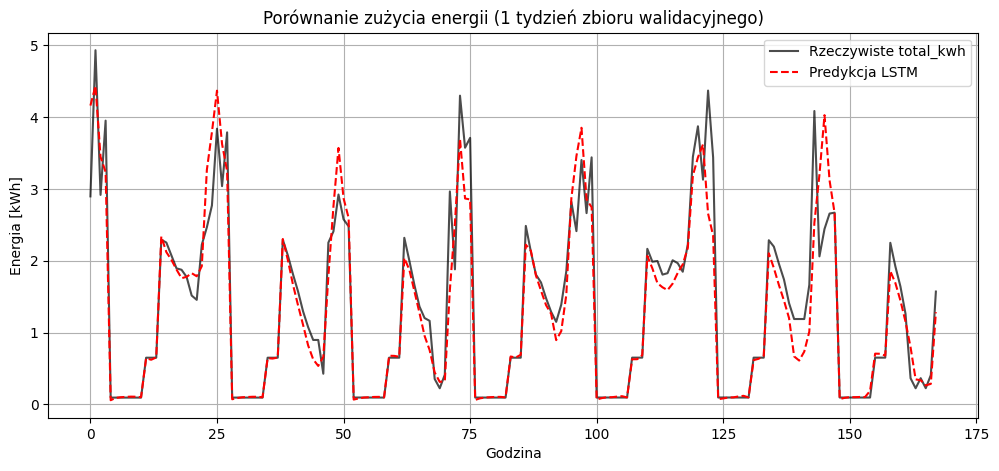

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. WCZYTANIE I PRZYGOTOWANIE DANYCH
# ==========================================
csv_path = 'household_full_profile.csv'
df = pd.read_csv(csv_path)

TARGET_COL = 'total_kwh'
feature_cols = [col for col in df.columns if col != TARGET_COL]

# Podział chronologiczny (80% trening, 20% walidacja)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:]

# Skalowanie cech do przedziału (0, 1)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(train_df[feature_cols])
y_train_scaled = scaler_y.fit_transform(train_df[[TARGET_COL]])

X_val_scaled = scaler_X.transform(val_df[feature_cols])
y_val_scaled = scaler_y.transform(val_df[[TARGET_COL]])

# Tworzenie okien sekwencji (ostatnie 24 godziny jako wejście)
WINDOW_SIZE = 24

def create_sequences(X, y, window_size=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i : i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_train_np, y_train_np = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)
X_val_np, y_val_np = create_sequences(X_val_scaled, y_val_scaled, WINDOW_SIZE)

print(f"X_train shape: {X_train_np.shape}")  # (próbki, 24, liczba_cech)
print(f"y_train shape: {y_train_np.shape}")  # (próbki, 1)

# ==========================================
# 2. TENSORY I DATALOADER PYTORCH
# ==========================================
train_dataset = TensorDataset(torch.tensor(X_train_np, dtype=torch.float32), 
                              torch.tensor(y_train_np, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val_np, dtype=torch.float32), 
                            torch.tensor(y_val_np, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# ==========================================
# 3. DEFINICJA MODELU LSTM
# ==========================================
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)         # out: (batch, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])  # bierzemy stan z ostatniego kroku czasowego
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Trening na urządzeniu: {device}")

model = LSTMRegressor(input_size=X_train_np.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 4. PĘTLA TRENUJĄCA Z WALIDACJĄ
# ==========================================
EPOCHS = 15

for epoch in range(EPOCHS):
    # Trening
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(batch_x)
    
    train_loss /= len(train_dataset)

    # Walidacja
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            val_loss += loss.item() * len(batch_x)
    
    val_loss /= len(val_dataset)
    print(f"Epoka {epoch+1:02d}/{EPOCHS} | Train MSE: {train_loss:.5f} | Val MSE: {val_loss:.5f}")

# ==========================================
# 5. PREDYKCJA I WYKRES (w kWh)
# ==========================================
model.eval()
all_preds = []
with torch.no_grad():
    for batch_x, _ in val_loader:
        batch_x = batch_x.to(device)
        preds = model(batch_x)
        all_preds.append(preds.cpu().numpy())

y_pred_scaled = np.vstack(all_preds)
y_pred_kwh = scaler_y.inverse_transform(y_pred_scaled)
y_true_kwh = scaler_y.inverse_transform(y_val_np)

# Wykres pierwszych 168 godzin (1 tydzień)
plt.figure(figsize=(12, 5))
plt.plot(y_true_kwh[:168], label='Rzeczywiste total_kwh', color='black', alpha=0.7)
plt.plot(y_pred_kwh[:168], label='Predykcja LSTM', color='red', linestyle='--')
plt.title('Porównanie zużycia energii (1 tydzień zbioru walidacyjnego)')
plt.xlabel('Godzina')
plt.ylabel('Energia [kWh]')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Standardowe metryki regresji
mae = mean_absolute_error(y_true_kwh, y_pred_kwh)
mse = mean_squared_error(y_true_kwh, y_pred_kwh)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_kwh, y_pred_kwh)

# 2. Średni błąd procentowy (MAPE)
mape = np.mean(np.abs((y_true_kwh - y_pred_kwh) / np.maximum(y_true_kwh, 1e-4))) * 100

# 3. "Tolerancyjne Accuracy" (procent predykcji z błędem mniejszym niż zadany margines)
# Np. błąd bezwzględny mniejszy niż 0.1 kWh
threshold_abs = 0.1
acc_abs = np.mean(np.abs(y_true_kwh - y_pred_kwh) <= threshold_abs) * 100

# Np. błąd względny mniejszy niż 15%
threshold_rel = 0.15
acc_rel = np.mean(np.abs((y_true_kwh - y_pred_kwh) / np.maximum(y_true_kwh, 1e-4)) <= threshold_rel) * 100

print("=" * 45)
print("             WYNIKI MODELU (EWALUACJA)       ")
print("=" * 45)
print(f"R² Score (Współczynnik dopasowania): {r2:.4f}  ({r2*100:.2f}%)")
print(f"MAE (Średni błąd bezwzględny):       {mae:.4f} kWh")
print(f"RMSE (Pierwiastek błędu kwadrat.):   {rmse:.4f} kWh")
print(f"MAPE (Średni błąd procentowy):       {mape:.2f} %")
print("-" * 45)
print(f"Accuracy (błąd <= {threshold_abs} kWh):          {acc_abs:.2f} %")
print(f"Accuracy (błąd <= {int(threshold_rel*100)}% wartości):        {acc_rel:.2f} %")
print("=" * 45)

             WYNIKI MODELU (EWALUACJA)       
R² Score (Współczynnik dopasowania): 0.7482  (74.82%)
MAE (Średni błąd bezwzględny):       0.2944 kWh
RMSE (Pierwiastek błędu kwadrat.):   0.5151 kWh
MAPE (Średni błąd procentowy):       49.41 %
---------------------------------------------
Accuracy (błąd <= 0.1 kWh):          46.66 %
Accuracy (błąd <= 15% wartości):        33.49 %


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. WCZYTANIE I INŻYNIERIA CECH (LAGI)
# ==========================================
df = pd.read_csv('household_full_profile.csv')

# Dodajemy kluczowe opóźnienia i trendy
df['lag_1'] = df['total_kwh'].shift(1)
df['lag_2'] = df['total_kwh'].shift(2)
df['lag_24'] = df['total_kwh'].shift(24)      # Wczoraj o tej samej porze
df['lag_168'] = df['total_kwh'].shift(168)    # Tydzień temu o tej samej porze
df['rolling_mean_6h'] = df['total_kwh'].shift(1).rolling(6).mean()
df['rolling_mean_24h'] = df['total_kwh'].shift(1).rolling(24).mean()

# Usuwamy pierwsze wiersze z wartościami NaN powstałymi przez przesunięcia (shift)
df = df.dropna().reset_index(drop=True)

TARGET_COL = 'total_kwh'
feature_cols = list(df.columns)  # Uwzględniamy wszystkie cechy wraz z historią total_kwh

# ==========================================
# 2. PODZIAŁ I STANDARYZACJA
# ==========================================
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(train_df[feature_cols])
y_train_scaled = scaler_y.fit_transform(train_df[[TARGET_COL]])

X_val_scaled = scaler_X.transform(val_df[feature_cols])
y_val_scaled = scaler_y.transform(val_df[[TARGET_COL]])

WINDOW_SIZE = 24

def create_sequences(X, y, window_size=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i : i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_train_np, y_train_np = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)
X_val_np, y_val_np = create_sequences(X_val_scaled, y_val_scaled, WINDOW_SIZE)

train_dataset = TensorDataset(torch.tensor(X_train_np, dtype=torch.float32), 
                              torch.tensor(y_train_np, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val_np, dtype=torch.float32), 
                            torch.tensor(y_val_np, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# ==========================================
# 3. ROZBUDOWANY MODEL LSTM
# ==========================================
class ImprovedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedLSTM(input_size=X_train_np.shape[2]).to(device)

# SmoothL1Loss (Huber Loss) jest znacznie bardziej odporny na szumy i piki
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ==========================================
# 4. TRENING (25 EPOK)
# ==========================================
EPOCHS = 20
print("Uruchamianie ulepszonego treningu...")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(bx)
    
    epoch_train_loss = total_loss / len(train_dataset)
    scheduler.step(epoch_train_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoka {epoch+1:02d}/{EPOCHS} | Loss: {epoch_train_loss:.5f}")

# ==========================================
# 5. EWALUACJA I NOWE WYNIKI ACCURACY
# ==========================================
model.eval()
preds = []
with torch.no_grad():
    for bx, _ in val_loader:
        preds.append(model(bx.to(device)).cpu().numpy())

y_pred_scaled = np.vstack(preds)
y_pred_kwh = scaler_y.inverse_transform(y_pred_scaled)
y_true_kwh = scaler_y.inverse_transform(y_val_np)

mae = mean_absolute_error(y_true_kwh, y_pred_kwh)
rmse = np.sqrt(mean_squared_error(y_true_kwh, y_pred_kwh))
r2 = r2_score(y_true_kwh, y_pred_kwh)
acc_abs = np.mean(np.abs(y_true_kwh - y_pred_kwh) <= 0.1) * 100
acc_rel = np.mean(np.abs((y_true_kwh - y_pred_kwh) / np.maximum(y_true_kwh, 1e-4)) <= 0.15) * 100

print("\n" + "=" * 45)
print("       ULEPSZONE WYNIKI MODELU (EWALUACJA)   ")
print("=" * 45)
print(f"R² Score:                            {r2:.4f}  ({r2*100:.2f}%)")
print(f"MAE (Średni błąd bezwzględny):       {mae:.4f} kWh")
print(f"RMSE (Pierwiastek błędu kwadrat.):   {rmse:.4f} kWh")
print("-" * 45)
print(f"Accuracy (błąd <= 0.1 kWh):          {acc_abs:.2f} %")
print(f"Accuracy (błąd <= 15% wartości):        {acc_rel:.2f} %")
print("=" * 45)

Uruchamianie ulepszonego treningu...
Epoka 01/20 | Loss: 0.16258
Epoka 05/20 | Loss: 0.06137
Epoka 10/20 | Loss: 0.05352
Epoka 15/20 | Loss: 0.04737
Epoka 20/20 | Loss: 0.04368

       ULEPSZONE WYNIKI MODELU (EWALUACJA)   
R² Score:                            0.8464  (84.64%)
MAE (Średni błąd bezwzględny):       0.2013 kWh
RMSE (Pierwiastek błędu kwadrat.):   0.3999 kWh
---------------------------------------------
Accuracy (błąd <= 0.1 kWh):          59.07 %
Accuracy (błąd <= 15% wartości):        61.21 %


In [56]:
import torch

checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_size': X_train_np.shape[2],
    'hidden_size': 128,
    'num_layers': 2,
    'window_size': WINDOW_SIZE,
    'feature_cols': feature_cols,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y
}

# Zapis do pliku .pth
model_path = 'lstm_household_model2.pth'
torch.save(checkpoint, model_path)

print(f"Model pomyślnie zapisany do: {model_path}")

Model pomyślnie zapisany do: lstm_household_model2.pth


Liczba wierszy: Train = 12163, Val = 2606, Test = 2607
Epoka 01/25 | Train Loss: 0.12709 | Val Loss: 0.08513 -> [Zapisano najlepszy model]
Epoka 02/25 | Train Loss: 0.07713 | Val Loss: 0.07245 -> [Zapisano najlepszy model]
Epoka 03/25 | Train Loss: 0.06932 | Val Loss: 0.06564 -> [Zapisano najlepszy model]
Epoka 05/25 | Train Loss: 0.05690 | Val Loss: 0.06087 -> [Zapisano najlepszy model]
Epoka 07/25 | Train Loss: 0.05287 | Val Loss: 0.05351 -> [Zapisano najlepszy model]
Epoka 09/25 | Train Loss: 0.05116 | Val Loss: 0.05150 -> [Zapisano najlepszy model]
Epoka 10/25 | Train Loss: 0.05086 | Val Loss: 0.07217 
Epoka 12/25 | Train Loss: 0.04671 | Val Loss: 0.04945 -> [Zapisano najlepszy model]
Epoka 15/25 | Train Loss: 0.04648 | Val Loss: 0.04987 
Epoka 20/25 | Train Loss: 0.03843 | Val Loss: 0.05199 
Epoka 25/25 | Train Loss: 0.03375 | Val Loss: 0.05249 


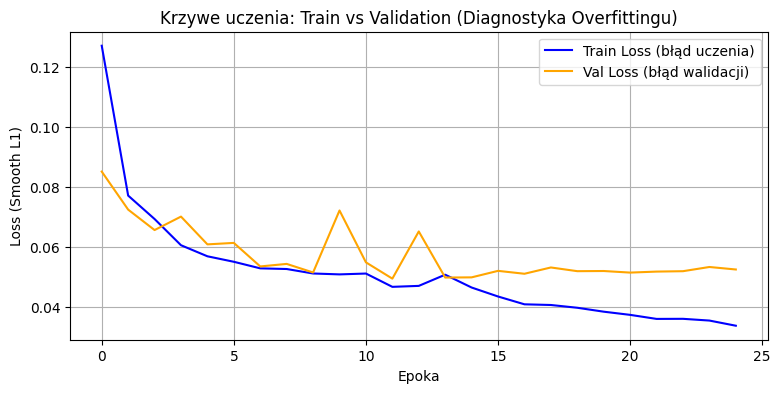


     OSTATECZNE WYNIKI NA DANYCH TESTOWYCH (TEST SET) 
R² Score na teście:                 0.8523 (85.23%)
MAE na teście:                      0.1962 kWh
RMSE na teście:                     0.3856 kWh
Accuracy w granicach 15%:           40.50 %


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. DANE I PODZIAŁ NA TRAIN (70%) / VAL (15%) / TEST (15%)
# ==========================================
df = pd.read_csv('household_full_profile.csv')

# Cechy inżynieryjne (Lagi)
df['lag_1'] = df['total_kwh'].shift(1)
df['lag_2'] = df['total_kwh'].shift(2)
df['lag_24'] = df['total_kwh'].shift(24)
df['lag_168'] = df['total_kwh'].shift(168)
df['rolling_mean_6h'] = df['total_kwh'].shift(1).rolling(6).mean()
df['rolling_mean_24h'] = df['total_kwh'].shift(1).rolling(24).mean()
df = df.dropna().reset_index(drop=True)

TARGET_COL = 'total_kwh'
feature_cols = list(df.columns)

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Liczba wierszy: Train = {len(train_df)}, Val = {len(val_df)}, Test = {len(test_df)}")

# Skalowanie (DOPASOWUJEMY WYŁĄCZNIE NA TRAIN - brak wycieku danych!)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(train_df[feature_cols])
y_train_s = scaler_y.fit_transform(train_df[[TARGET_COL]])

X_val_s = scaler_X.transform(val_df[feature_cols])
y_val_s = scaler_y.transform(val_df[[TARGET_COL]])

X_test_s = scaler_X.transform(test_df[feature_cols])
y_test_s = scaler_y.transform(test_df[[TARGET_COL]])

WINDOW_SIZE = 24

def create_sequences(X, y, window_size=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i : i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_train_np, y_train_np = create_sequences(X_train_s, y_train_s, WINDOW_SIZE)
X_val_np, y_val_np = create_sequences(X_val_s, y_val_s, WINDOW_SIZE)
X_test_np, y_test_np = create_sequences(X_test_s, y_test_s, WINDOW_SIZE)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train_np, dtype=torch.float32), torch.tensor(y_train_np, dtype=torch.float32)), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_np, dtype=torch.float32), torch.tensor(y_val_np, dtype=torch.float32)), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_np, dtype=torch.float32), torch.tensor(y_test_np, dtype=torch.float32)), batch_size=64, shuffle=False)

# ==========================================
# 2. MODEL I TRENING
# ==========================================
class ImprovedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedLSTM(input_size=X_train_np.shape[2]).to(device)

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Do śledzenia overfittingu
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
EPOCHS = 25

for epoch in range(EPOCHS):
    # Faza trenowania
    model.train()
    t_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * len(bx)
    train_loss = t_loss / len(train_loader.dataset)

    # Faza walidacji
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            loss = criterion(model(bx), by)
            v_loss += loss.item() * len(bx)
    val_loss = v_loss / len(val_loader.dataset)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step(val_loss)

    # ZAPISUJEMY MODEL TYLKO GDY VAL_LOSS SIĘ POPRAWIA (Ochrona przed overfittingiem!)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm_weights.pth')
        saved_flag = "-> [Zapisano najlepszy model]"
    else:
        saved_flag = ""

    if (epoch + 1) % 5 == 0 or epoch == 0 or saved_flag:
        print(f"Epoka {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f} {saved_flag}")

# ==========================================
# 3. SPRAWDZENIE OVERFITTINGU NA WYKRESIE
# ==========================================
plt.figure(figsize=(9, 4))
plt.plot(history['train_loss'], label='Train Loss (błąd uczenia)', color='blue')
plt.plot(history['val_loss'], label='Val Loss (błąd walidacji)', color='orange')
plt.title('Krzywe uczenia: Train vs Validation (Diagnostyka Overfittingu)')
plt.xlabel('Epoka')
plt.ylabel('Loss (Smooth L1)')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 4. OSTATECZNA EWALUACJA NA ZBIORZE TESTOWYM (TEST SET)
# ==========================================
# Ładujemy wagi z najlepszej epoki walidacyjnej
model.load_state_dict(torch.load('best_lstm_weights.pth'))
model.eval()

test_preds = []
with torch.no_grad():
    for bx, _ in test_loader:
        test_preds.append(model(bx.to(device)).cpu().numpy())

y_test_pred_kwh = scaler_y.inverse_transform(np.vstack(test_preds))
y_test_true_kwh = scaler_y.inverse_transform(y_test_np)

mae = mean_absolute_error(y_test_true_kwh, y_test_pred_kwh)
rmse = np.sqrt(mean_squared_error(y_test_true_kwh, y_test_pred_kwh))
r2 = r2_score(y_test_true_kwh, y_test_pred_kwh)
acc_15 = np.mean(np.abs((y_test_true_kwh - y_test_pred_kwh) / np.maximum(y_test_true_kwh, 1e-4)) <= 0.15) * 100

print("\n" + "=" * 50)
print("     OSTATECZNE WYNIKI NA DANYCH TESTOWYCH (TEST SET) ")
print("=" * 50)
print(f"R² Score na teście:                 {r2:.4f} ({r2*100:.2f}%)")
print(f"MAE na teście:                      {mae:.4f} kWh")
print(f"RMSE na teście:                     {rmse:.4f} kWh")
print(f"Accuracy w granicach 15%:           {acc_15:.2f} %")
print("=" * 50)

Epoka 01 | Train: 0.17283 | Val: 0.10144 -> [Zapisano najlepszy model]
Epoka 02 | Train: 0.10422 | Val: 0.08811 -> [Zapisano najlepszy model]
Epoka 03 | Train: 0.09099 | Val: 0.07641 -> [Zapisano najlepszy model]
Epoka 04 | Train: 0.08239 | Val: 0.06943 -> [Zapisano najlepszy model]
Epoka 05 | Train: 0.07972 | Val: 0.06695 -> [Zapisano najlepszy model]
Epoka 06 | Train: 0.07598 | Val: 0.06752 (Brak poprawy: 1/6)
Epoka 07 | Train: 0.07497 | Val: 0.06811 (Brak poprawy: 2/6)
Epoka 08 | Train: 0.07105 | Val: 0.05784 -> [Zapisano najlepszy model]
Epoka 09 | Train: 0.07048 | Val: 0.05491 -> [Zapisano najlepszy model]
Epoka 10 | Train: 0.06955 | Val: 0.06154 (Brak poprawy: 1/6)
Epoka 11 | Train: 0.06841 | Val: 0.05789 (Brak poprawy: 2/6)
Epoka 12 | Train: 0.06621 | Val: 0.05513 (Brak poprawy: 3/6)
Epoka 13 | Train: 0.06245 | Val: 0.05184 -> [Zapisano najlepszy model]
Epoka 14 | Train: 0.05991 | Val: 0.05186 (Brak poprawy: 1/6)
Epoka 15 | Train: 0.06178 | Val: 0.05202 (Brak poprawy: 2/6)
Epoka

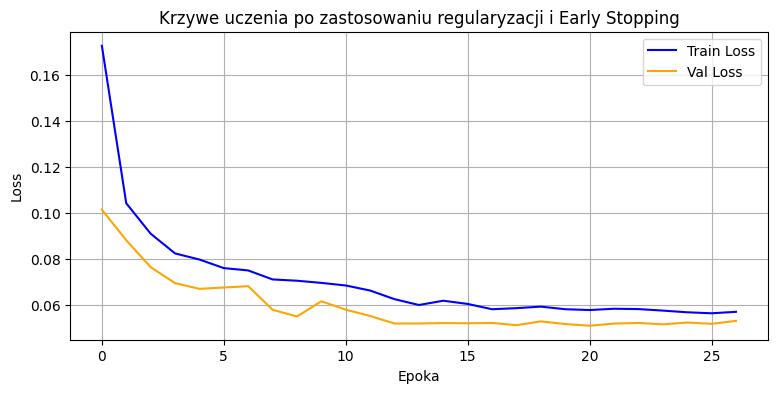

R² na zbiorze Test:           0.8490
MAE na zbiorze Test:          0.2061 kWh


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. ZMODYFIKOWANA ARCHITEKTURA (Z SILNIEJSZĄ REGULARYZACJĄ)
# ==========================================
class RegularizedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        # Zmniejszono hidden_size do 64 i zwiększono dropout do 0.3
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RegularizedLSTM(input_size=X_train_np.shape[2], hidden_size=64, num_layers=2, dropout=0.3).to(device)

criterion = nn.SmoothL1Loss()
# Silniejsza regularyzacja L2 (weight_decay=1e-3)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# ==========================================
# 2. PĘTLA Z MECHANIZMEM EARLY STOPPING
# ==========================================
PATIENCE = 6          # Po ilu epokach bez poprawy przerywamy
patience_counter = 0
best_val_loss = float('inf')
EPOCHS = 50

history = {'train_loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    # Trening
    model.train()
    t_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * len(bx)
    train_loss = t_loss / len(train_loader.dataset)

    # Walidacja
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            v_loss += criterion(model(bx), by).item() * len(bx)
    val_loss = v_loss / len(val_loader.dataset)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step(val_loss)

    # Early Stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm_weights.pth')
        patience_counter = 0
        saved_info = "-> [Zapisano najlepszy model]"
    else:
        patience_counter += 1
        saved_info = f"(Brak poprawy: {patience_counter}/{PATIENCE})"

    print(f"Epoka {epoch+1:02d} | Train: {train_loss:.5f} | Val: {val_loss:.5f} {saved_info}")

    if patience_counter >= PATIENCE:
        print(f"\n[!] Early Stopping aktywowane w epoce {epoch+1} – zapobiegnięto przeuczeniu.")
        break

# ==========================================
# 3. NOWY WYKRES PO REGULARYZACJI
# ==========================================
plt.figure(figsize=(9, 4))
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('Krzywe uczenia po zastosowaniu regularyzacji i Early Stopping')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 4. TEST NA CZYSTYCH DANYCH
# ==========================================
model.load_state_dict(torch.load('best_lstm_weights.pth'))
model.eval()

test_preds = []
with torch.no_grad():
    for bx, _ in test_loader:
        test_preds.append(model(bx.to(device)).cpu().numpy())

y_test_pred_kwh = scaler_y.inverse_transform(np.vstack(test_preds))
y_test_true_kwh = scaler_y.inverse_transform(y_test_np)

print("=" * 45)
print(f"R² na zbiorze Test:           {r2_score(y_test_true_kwh, y_test_pred_kwh):.4f}")
print(f"MAE na zbiorze Test:          {mean_absolute_error(y_test_true_kwh, y_test_pred_kwh):.4f} kWh")
print("=" * 45)

In [ ]:
# Procent predykcji, gdzie błąd nie przekroczył 15% rzeczywistej wartości:
acc_15 = np.mean(np.abs((y_test_true_kwh - y_test_pred_kwh) / np.maximum(y_test_true_kwh, 1e-4)) <= 0.15) * 100(

# Procent predykcji, gdzie model pomylił się o mniej niż 0.1 kWh:
acc_01 = np.mean(np.absy_test_true_kwh - y_test_pred_kwh) <= 0.1) * 100

print(f"Accuracy w marginesie błędu 15%: {acc_15:.1f}%")
print(f"Accuracy w marginesie błędu 0.1 kWh: {acc_01:.1f}%")

Accuracy w marginesie błędu 15%: 42.7%
Accuracy w marginesie błędu 0.1 kWh: 56.9%


In [66]:
import torch
import numpy as np
import pandas as pd

def predict_energy_consumption(input_df_24h, model, scaler_X, scaler_y, device):
    """
    input_df_24h: DataFrame zawierający dokładnie 24 ostatnie wiersze (godziny) 
                  ze wszystkimi cechami (pogoda z API + kalendarz + urządzenia/historia)
    """
    model.eval()
    
    # 1. Przeskalowanie danych wejściowych skalerem dopasowanym podczas treningu
    X_scaled = scaler_X.transform(input_df_24h)  # shape: (24, num_features)
    
    # 2. Dodanie wymiaru batcha: (1, 24, num_features)
    tensor_input = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    
    # 3. Predykcja modelu
    with torch.no_grad():
        pred_scaled = model(tensor_input).cpu().numpy()
        
    # 4. Odwrócenie skalera do rzeczywistych jednostek (kWh)
    predicted_kwh = scaler_y.inverse_transform(pred_scaled)[0, 0]
    
    return float(predicted_kwh)

# Przykład użycia:
# next_hour_kwh = predict_energy_consumption(last_24h_data, loaded_model, scaler_X, scaler_y, device)
# print(f"Przewidywane zużycie na kolejną godzinę: {next_hour_kwh:.3f} kWh")

In [67]:
next_hour_kwh = predict_energy_consumption(last_24h_data, loaded_model, scaler_X, scaler_y, device)
print(f"Przewidywane zużycie na kolejną godzinę: {next_hour_kwh:.3f} kWh")

NameError: name 'last_24h_data' is not defined

In [68]:
import pandas as pd

# Tworzymy tabelę podsumowującą predykcje vs rzeczywistość
df_wyniki = pd.DataFrame({
    'Rzeczywiste total_kwh': y_test_true_kwh.flatten(),
    'Predykcja modelu':      y_test_pred_kwh.flatten(),
})

# Obliczamy różnicę (o ile model się pomylił)
df_wyniki['Różnica (błąd w kWh)'] = (df_wyniki['Predykcja modelu'] - df_wyniki['Rzeczywiste total_kwh']).abs()

# Podgląd pierwszych 10 przewidzianych godzin
print("--- PRZYKŁADOWE PREDYKCJE MODELU DLA KOLEJNYCH GODZIN ---")
print(df_wyniki.head(10).round(4))

--- PRZYKŁADOWE PREDYKCJE MODELU DLA KOLEJNYCH GODZIN ---
   Rzeczywiste total_kwh  Predykcja modelu  Różnica (błąd w kWh)
0                 1.7213            1.8078                0.0865
1                 1.3021            1.5101                0.2080
2                 1.1530            1.0316                0.1214
3                 0.2236            0.6312                0.4076
4                 0.2241            0.4549                0.2308
5                 1.0247            0.4388                0.5859
6                 1.1649            0.9417                0.2232
7                 1.0249            0.7776                0.2473
8                 0.3087            0.9884                0.6797
9                 1.2516            1.3052                0.0536


Analizowanie ważności cech dla celu: total_kwh...

--- TOP 15 NAJWAŻNIEJSZYCH CECH DLA TOTAL_KWH ---
                 cecha  waznosc
electric_heat_pump_kwh 0.519485
  air_conditioning_kwh 0.195416
     induction_hob_kwh 0.067692
    phone_charging_kwh 0.058289
          lighting_kwh 0.042405
   laptop_computer_kwh 0.027411
              oven_kwh 0.026683
        dishwasher_kwh 0.024984
   washing_machine_kwh 0.012282
        temperature_2m 0.010486
        heating_demand 0.006185
      refrigerator_kwh 0.002698
  temp_rolling_mean_6h 0.001575
    gaming_console_kwh 0.000522
        television_kwh 0.000446

--- 10 NAJMNIEJ WAŻNYCH CECH (KANDYDACI DO USUNIĘCIA) ---
              cecha      waznosc
           cos_hour 2.390989e-05
         is_weekend 1.755837e-05
     girl_at_office 1.222313e-05
      man_at_office 4.916121e-06
     pet_camera_kwh 9.488824e-07
          is_dog_in 8.954088e-07
     pet_feeder_kwh 7.926323e-07
       weekend_away 4.847655e-07
    wifi_router_kwh 0.000000e+0

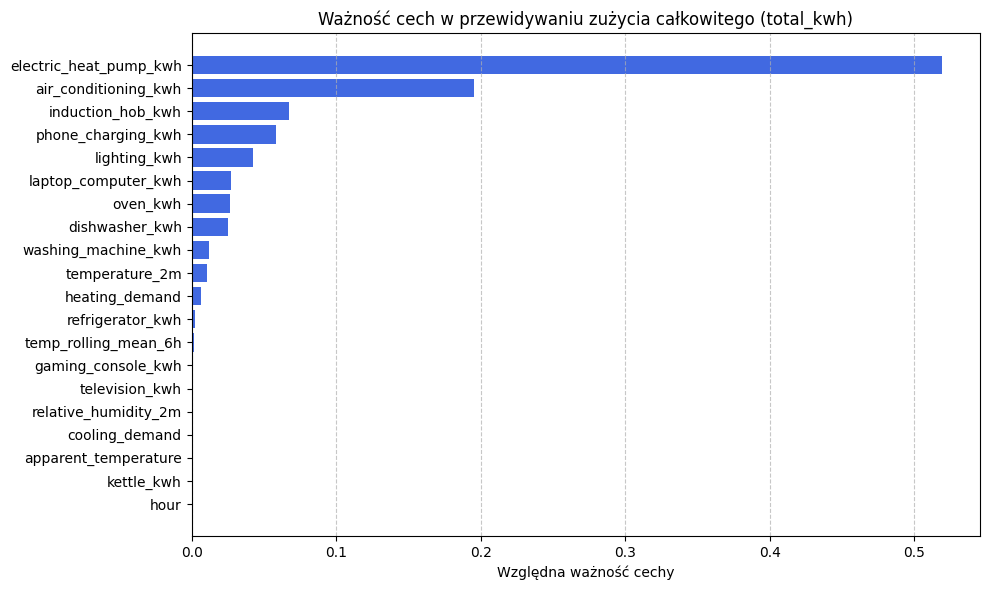

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# 1. Wczytanie danych
df = pd.read_csv('household_full_profile.csv')

# 2. Definicja wejścia X i celu y
y = df['total_kwh']
X = df.drop(columns=['total_kwh'])

# 3. Podział czasowy (bez tasowania)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Szybki i dokładny model nieliniowy do oceny ważności cech
print("Analizowanie ważności cech dla celu: total_kwh...")
rf = RandomForestRegressor(n_estimators=60, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 5. Wyznaczenie ważności cech (Feature Importance)
importance_df = pd.DataFrame({
    'cecha': X.columns,
    'waznosc': rf.feature_importances_
}).sort_values(by='waznosc', ascending=False)

print("\n--- TOP 15 NAJWAŻNIEJSZYCH CECH DLA TOTAL_KWH ---")
print(importance_df.head(15).to_string(index=False))

print("\n--- 10 NAJMNIEJ WAŻNYCH CECH (KANDYDACI DO USUNIĘCIA) ---")
print(importance_df.tail(10).to_string(index=False))

# Wykres 20 najważniejszych cech
plt.figure(figsize=(10, 6))
top_20 = importance_df.head(20).iloc[::-1]
plt.barh(top_20['cecha'], top_20['waznosc'], color='royalblue')
plt.title('Ważność cech w przewidywaniu zużycia całkowitego (total_kwh)')
plt.xlabel('Względna ważność cechy')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()